# Эллиптические кривые

Вот так выглядит эллиптическая кривая над множеством $\Z_p$ - множеством целых чисел по модулю $p$ - задается тремя параметрами, но подбирается очень тяжело, а значит можно использовать ее в криптографии

Зададим константы кривой и функцию сложения точек (см [статью на Хабре](https://habr.com/ru/articles/335906/))

In [9]:
import time
from sympy import nextprime
import matplotlib.pyplot as plt

In [10]:
def add_points(P, Q, a: float, p: int):
    if P == 'O':
        return Q
    if Q == 'O':
        return P

    x1, y1 = P
    x2, y2 = Q

    if x1 == x2 and (y1 + y2) % p == 0:
        return 'O'

    if P != Q:
        m = (y2 - y1) * pow(x2 - x1, -1, p) % p
    else:
        m = (3*x1**2 + a) * pow(2*y1, -1, p) % p

    x3 = (m**2 - x1 - x2) % p
    y3 = (m*(x1 - x3) - y1) % p

    return (x3, y3)


def is_on_curve(P, a: float, b: float, p: int):
    if P == 'O':
        return True
    x, y = P
    return (y**2 - x**3 - a*x - b) % p == 0


def get_starting_point(a: float, b: float, p: int, max_x: int = int(1e4), max_y: int = int(1e4)) -> tuple[int, int] | str:
    for x in range(max_x):
        for y in range(max_y):
            P = (x, y)
            if is_on_curve(P, a, b, p):
                return P

    return 'O'

Немного визуализации

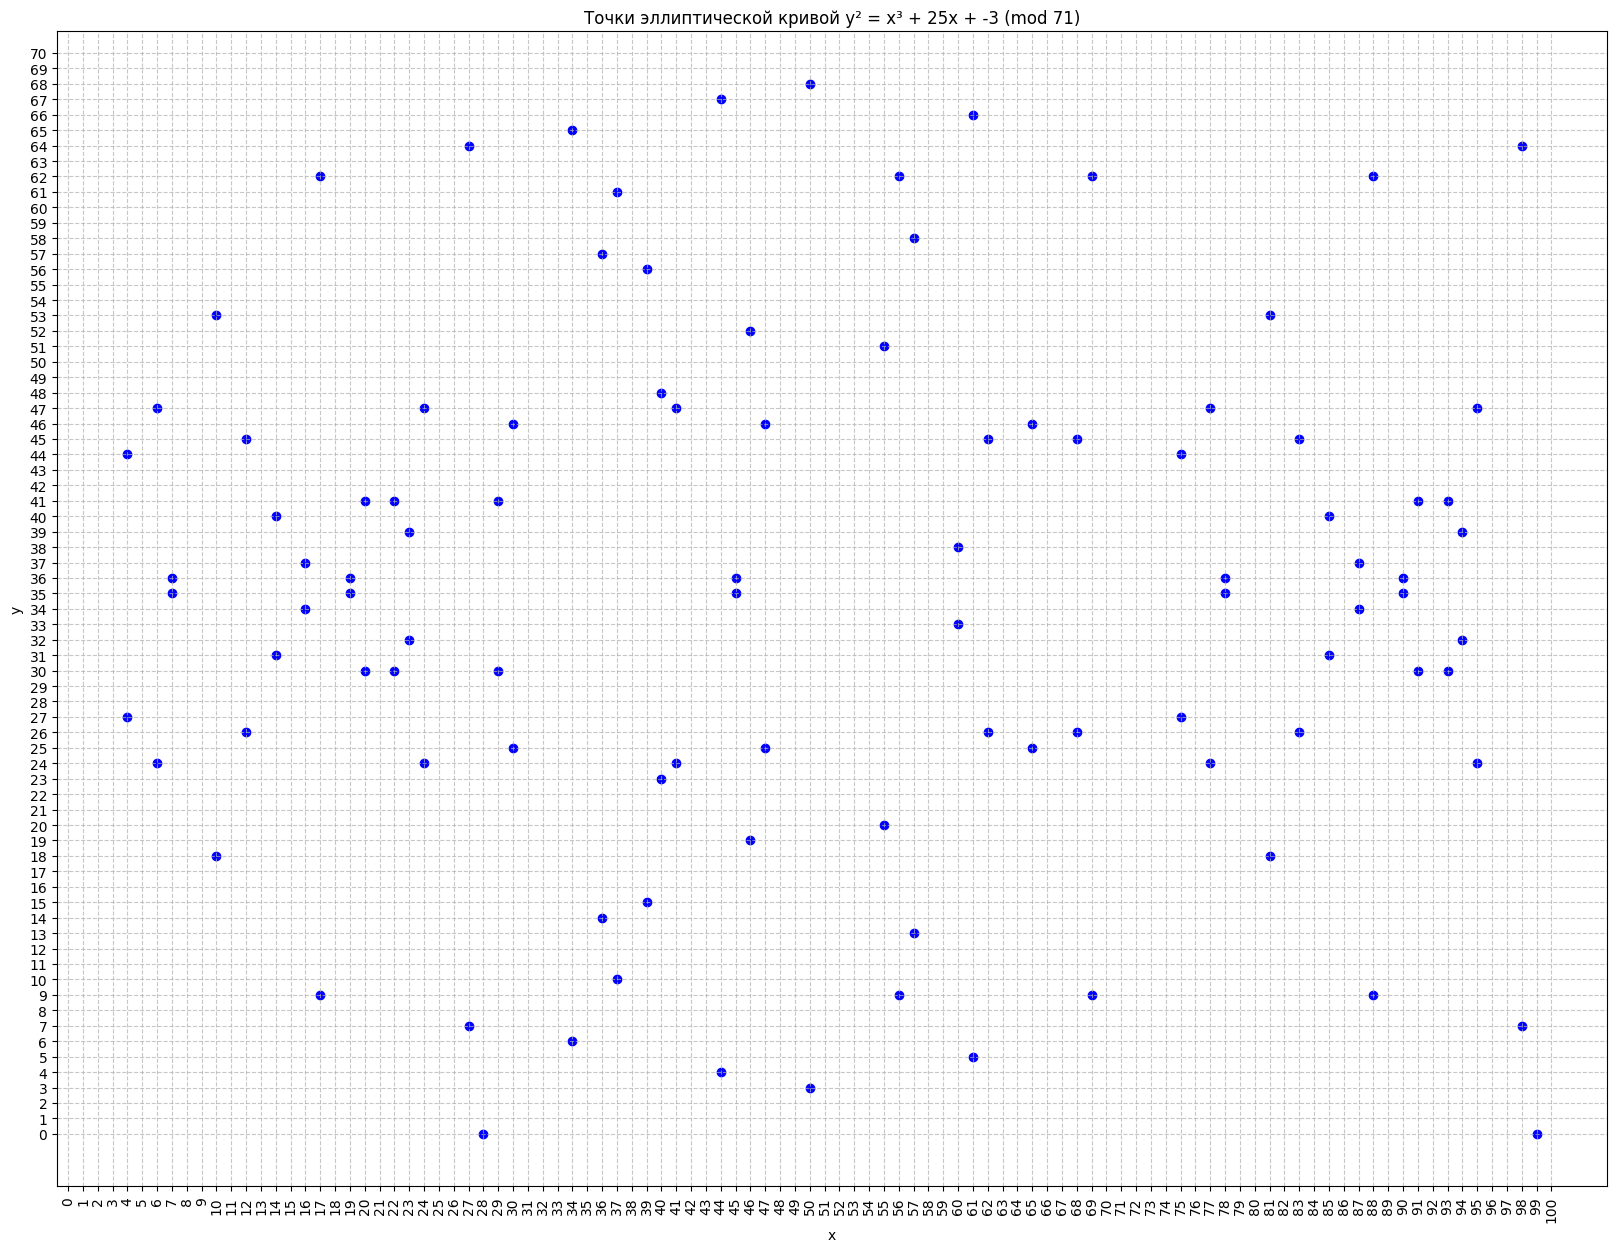

In [11]:
a = 25
b = -3
p: int = nextprime(69)

assert (4*a**3 + 27*b**2) % p != 0, "Кривая вырождена"

max_x = 100

points = []
for x in range(max_x):
    for y in range(p):
        if is_on_curve((x, y), a, b, p):
            points.append((x, y))


plt.figure(figsize=(20, 15))
plt.title(f"Точки эллиптической кривой y² = x³ + {a}x + {b} (mod {p})")
plt.xlabel("x")
plt.ylabel("y")

x_coords = [point[0] for point in points]
y_coords = [point[1] for point in points]
plt.scatter(x_coords, y_coords, color='blue')

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(0, max_x + 1))
plt.xticks(rotation=90)
plt.yticks(range(0, p))
plt.show()

В алгоритмах, связанных с эллиптическими кривыми важен порядок циклической подгруппы -- чтобы задать создать пару ключей для шифрования, можно использовать следующий подход:

Генерируем общие переменные (обмениваемся ими как угодно):
- $p$, $a$, $b$ -- исходные параметры кривой
- $G$ -- точка, порождающая подгруппу

Закрытый ключ -- $d$ -- случайное число от 0 до $n - 1$, где $n$ -- порядок подгруппы
, открытый ключ -- $H = dG$

При обмене сторонами открытыми ключами $H_A$ и $H_B$ можно вычислить число $S = d_AH_B = d_Ad_BG = d_Bd_AG = d_BH_A$

Собственно число $d$ нам и нужно найти


## Поиск порядка подгруппы полным перебор

In [12]:
p: int = nextprime(5e8)
s_sp = time.time()
starting_point = get_starting_point(a, b, p)
e_sp = time.time()
print(f"Время поиска начальной точки: {e_sp - s_sp:.2f} сек")


def bruteforce_find_point_order(P, a, p):
    if P == 'O':
        return 1

    current = P
    order = 1

    while current != 'O':
        current = add_points(current, P, a, p)
        order += 1

    return order


s_bf = time.time()
order = bruteforce_find_point_order(starting_point, a, p)
e_bf = time.time()

print(f"Порядок точки {starting_point}: {order}")
print(f"Время поиска полным перебором: {e_bf - s_bf:.2f} сек")

Время поиска начальной точки: 0.07 сек
Порядок точки (12, 45): 500000656
Время поиска полным перебором: 889.84 сек


## Алгоритм Шуфа

Для более эффективного алгоритма поиска порядка подгруппы, можно использовать Алгоритм Шуфа, который находит порядок группы, а после этого, перебирая $n$ с его наименьшего делителя проверять равняется ли $nP\ \%\ p$ нулю. Если да, то нашли порядок подгруппы

In [13]:
# sudo apt install sagemath
import subprocess


code = f'''
e = EllipticCurve(GF({p}), [{a}, {b}])
e.order()
'''

s_sc = time.time()
sage = subprocess.run(f'echo "{code}" | sage', shell=True,
                      text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
e_sc = time.time()

order = sage.stdout.splitlines()[-2]

print(f"Порядок точки {starting_point}: {order}")
print(f"Время поиска алгоритмом Шуфа: {e_sc - s_sc:.2f} сек")

Порядок точки (12, 45): 500000656
Время поиска алгоритмом Шуфа: 1.39 сек
